Dataset loaded successfully.
Shape of dataset: (569, 31)

First 5 rows:
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dime

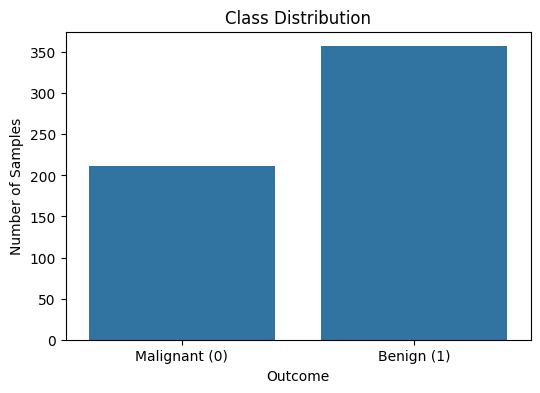

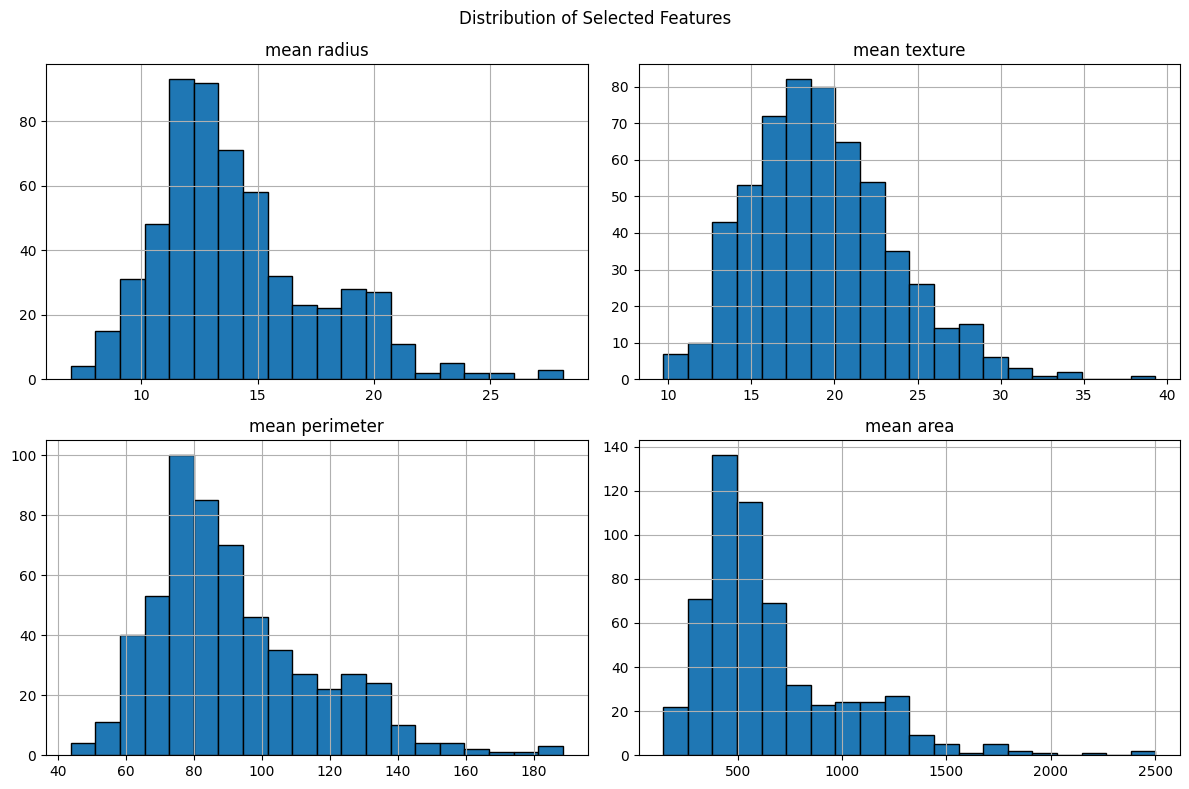

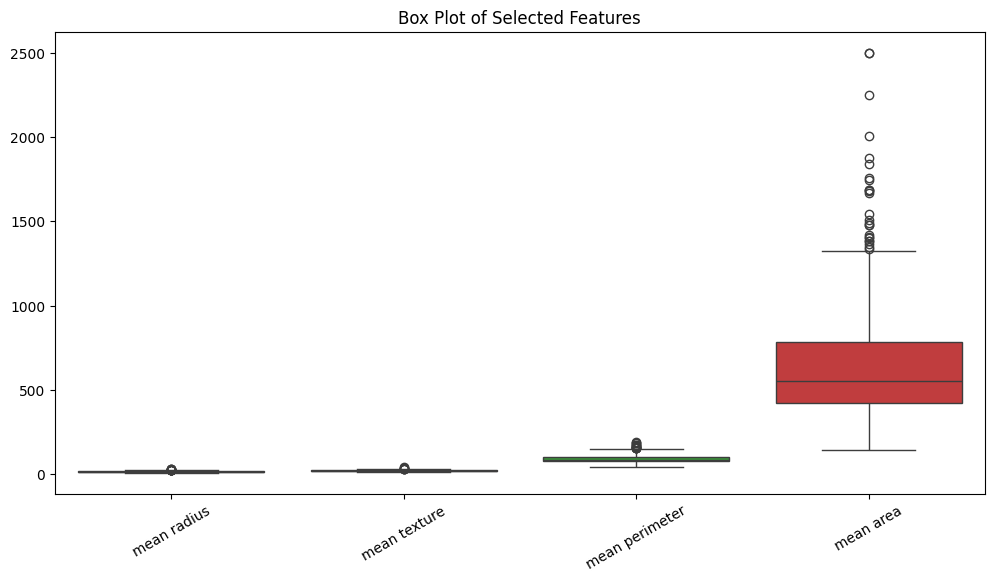

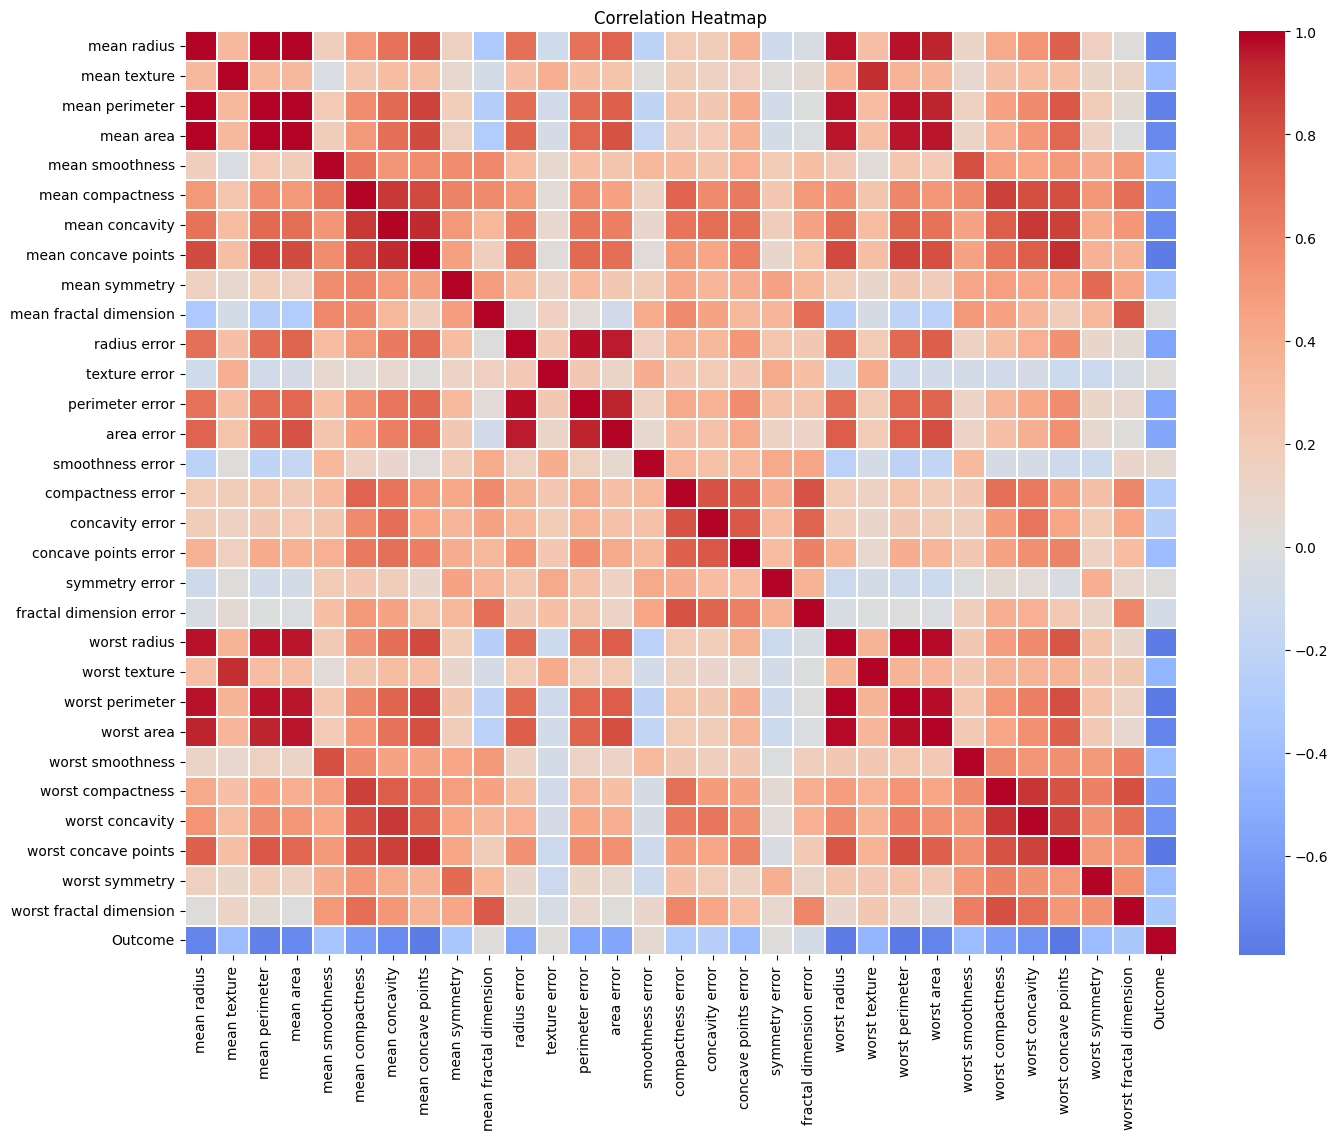


Outlier Summary:
                Feature  Number_of_Outliers
            mean radius                  14
           mean texture                   7
         mean perimeter                  13
              mean area                  25
        mean smoothness                   6
       mean compactness                  16
         mean concavity                  18
    mean concave points                  10
          mean symmetry                  15
 mean fractal dimension                  15
           radius error                  38
          texture error                  20
        perimeter error                  38
             area error                  65
       smoothness error                  30
      compactness error                  28
        concavity error                  22
   concave points error                  19
         symmetry error                  27
fractal dimension error                  28
           worst radius                  17
          wors

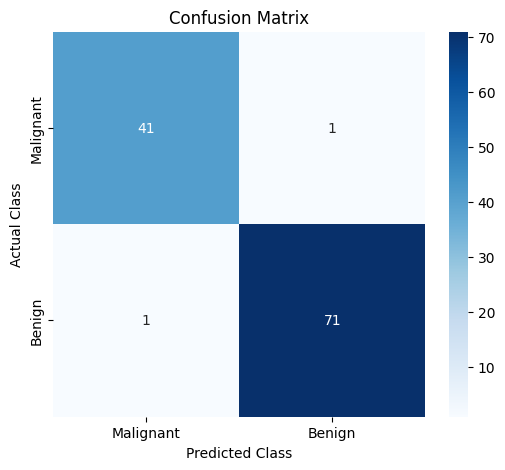


ROC-AUC Score: 0.9954


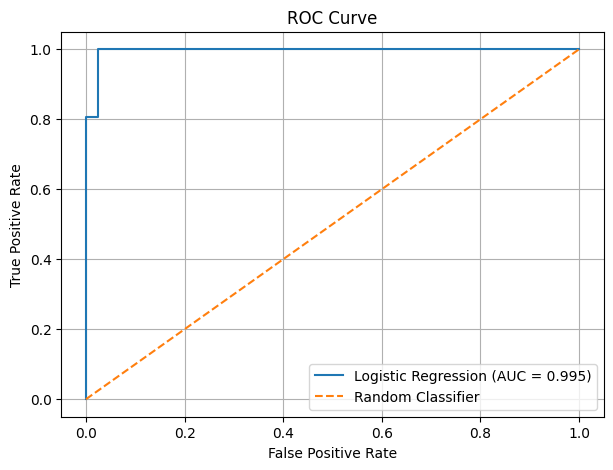


Most influential features:
             Feature  Coefficient  Absolute_Coefficient
       worst texture    -1.255088              1.255088
        radius error    -1.082965              1.082965
worst concave points    -0.953686              0.953686
          worst area    -0.947756              0.947756
        worst radius    -0.947616              0.947616
      worst symmetry    -0.939181              0.939181
          area error    -0.929104              0.929104
     worst concavity    -0.823151              0.823151
     worst perimeter    -0.763220              0.763220
    worst smoothness    -0.746625              0.746625


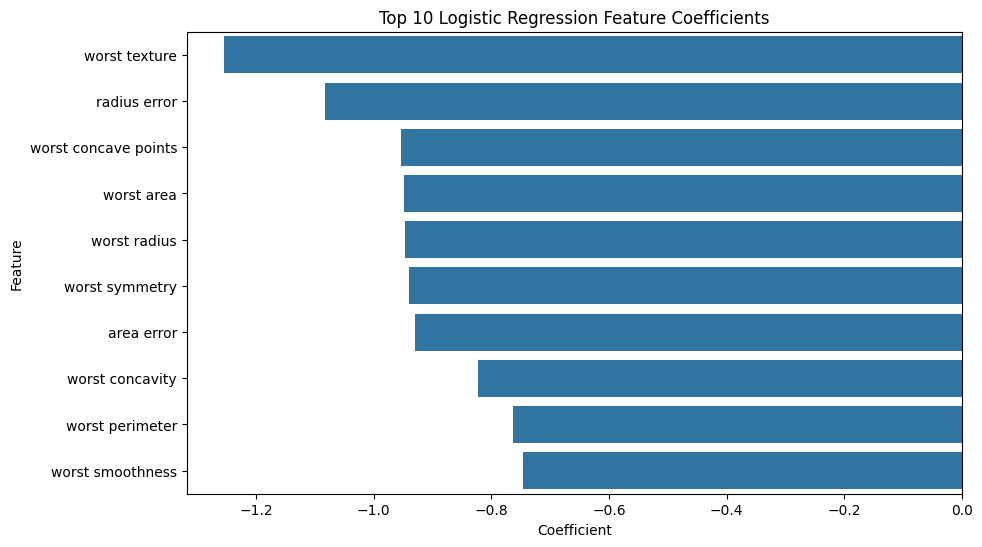


================ FINAL RESULTS ================
Accuracy : 0.9825
Precision - Malignant: 0.9762
Precision - Benign: 0.9861
Recall - Malignant: 0.9762
Recall - Benign: 0.9861
F1 - Malignant: 0.9762
F1 - Benign: 0.9861
ROC-AUC: 0.9954


In [9]:
# Basic libraries
import os
import re
import numpy as np

# 1. Import required libraries


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

# For reproducible results
np.random.seed(42)

# TASK 1: DATA ACQUISITION AND EXPLORATION



# 1. Load the dataset


data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="Outcome")

# Combine features and target into one dataframe
df = X.copy()
df["Outcome"] = y

print("Dataset loaded successfully.")
print("Shape of dataset:", df.shape)

print("\nFirst 5 rows:")
print(df.head())

# 2. Basic information

print("\nDataset Information:")
print(df.info())

print("\nColumn names:")
print(df.columns.tolist())

# 3. Summary statistics

print("\nSummary Statistics:")
print(df.describe().T)

print("\nMedian of all numerical features:")
print(df.median())

# 4. Check missing values

print("\nMissing Values:")
print(df.isnull().sum())

print("\nTotal missing values:", df.isnull().sum().sum())

# 5. Check duplicate rows

print("\nNumber of duplicate rows:", df.duplicated().sum())


# Remove duplicate rows if present
df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)


# 6. Check target distribution

print("\nTarget Class Distribution:")
print(df["Outcome"].value_counts())

print("\nTarget Class Percentage:")
print(df["Outcome"].value_counts(normalize=True) * 100)

# VISUALIZATION
# 7. Class distribution

plt.figure(figsize=(6, 4))

sns.countplot(x="Outcome", data=df)

plt.title("Class Distribution")
plt.xlabel("Outcome")
plt.ylabel("Number of Samples")

plt.xticks(
    [0, 1],
    ["Malignant (0)", "Benign (1)"]
)

plt.show()

# 8. Histograms of selected features


selected_features = [
    "mean radius",
    "mean texture",
    "mean perimeter",
    "mean area"
]

df[selected_features].hist(
    figsize=(12, 8),
    bins=20,
    edgecolor="black"
)

plt.suptitle("Distribution of Selected Features")
plt.tight_layout()
plt.show()

# 9. Box plots for outlier detection


plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df[
        [
            "mean radius",
            "mean texture",
            "mean perimeter",
            "mean area"
        ]
    ]
)

plt.title("Box Plot of Selected Features")
plt.xticks(rotation=30)
plt.show()

# 10. Correlation heatmap

plt.figure(figsize=(16, 12))

correlation_matrix = df.corr()

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0,
    linewidths=0.3
)

plt.title("Correlation Heatmap")
plt.show()

# OUTLIER CHECK

# 11. Detect outliers using IQR


numeric_features = X.columns

outlier_summary = {}

for column in numeric_features:

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    outliers = df[
        (df[column] < lower_limit) |
        (df[column] > upper_limit)
    ]

    outlier_summary[column] = len(outliers)

outlier_df = pd.DataFrame(
    list(outlier_summary.items()),
    columns=["Feature", "Number_of_Outliers"]
)

print("\nOutlier Summary:")
print(outlier_df.to_string(index=False))

# TASK 2: DATA PREPROCESSING

# 12. Separate features and target

X = df.drop("Outcome", axis=1)
y = df["Outcome"]

print("\nFeature shape:", X.shape)
print("Target shape:", y.shape)



# 13. Train-test split


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

print("\nTraining class distribution:")
print(y_train.value_counts())

print("\nTesting class distribution:")
print(y_test.value_counts())


# 14. Standardize features


scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("\nFeature standardization completed.")

# TASK 3: MODEL TRAINING

# 15. Train Logistic Regression
model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model.fit(X_train_scaled, y_train)

print("\nLogistic Regression model trained successfully.")


# 16. Make predictions

y_pred = model.predict(X_test_scaled)

# Probability of class 1
y_prob = model.predict_proba(X_test_scaled)[:, 1]


# MODEL EVALUATION
# 17. Accuracy

accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy:", round(accuracy, 4))


# 18. Precision

precision = precision_score(
    y_test,
    y_pred,
    average=None
)

print("\nPrecision:")
print("Class 0:", round(precision[0], 4))
print("Class 1:", round(precision[1], 4))


# 19. Recall

recall = recall_score(
    y_test,
    y_pred,
    average=None
)

print("\nRecall:")
print("Class 0:", round(recall[0], 4))
print("Class 1:", round(recall[1], 4))



# 20. F1 Score


f1 = f1_score(
    y_test,
    y_pred,
    average=None
)

print("\nF1 Score:")
print("Class 0:", round(f1[0], 4))
print("Class 1:", round(f1[1], 4))

# 21. Complete classification report

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Malignant", "Benign"]
    )
)

# CONFUSION MATRIX

# 22. Confusion Matrix

cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)

# 23. Visualize confusion matrix

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Malignant", "Benign"],
    yticklabels=["Malignant", "Benign"]
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.show()

# ROC CURVE AND AUC

# 24. Calculate ROC curve

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob
)

# Calculate AUC
auc_score = roc_auc_score(
    y_test,
    y_prob
)

print("\nROC-AUC Score:", round(auc_score, 4))


# 25. Plot ROC curve


plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f"Logistic Regression (AUC = {auc_score:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.grid()

plt.show()

# MODEL INTERPRETATION

# 26. Feature coefficients

coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

coefficients["Absolute_Coefficient"] = (
    coefficients["Coefficient"].abs()
)

coefficients = coefficients.sort_values(
    by="Absolute_Coefficient",
    ascending=False
)

print("\nMost influential features:")
print(coefficients.head(10).to_string(index=False))

# 27. Plot top feature coefficients

top_features = coefficients.head(10)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_features,
    x="Coefficient",
    y="Feature"
)

plt.title("Top 10 Logistic Regression Feature Coefficients")

plt.xlabel("Coefficient")
plt.ylabel("Feature")

plt.show()


# FINAL RESULTS SUMMARY


print("\n---FINAL RESULTS--")

print("Accuracy :", round(accuracy, 4))

print(
    "Precision - Malignant:",
    round(precision[0], 4)
)

print(
    "Precision - Benign:",
    round(precision[1], 4)
)

print(
    "Recall - Malignant:",
    round(recall[0], 4)
)

print(
    "Recall - Benign:",
    round(recall[1], 4)
)

print(
    "F1 - Malignant:",
    round(f1[0], 4)
)

print(
    "F1 - Benign:",
    round(f1[1], 4)
)

print(
    "ROC-AUC:",
    round(auc_score, 4)
)

print("================================================")